In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph
from langgraph.graph import START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition

import os
from dotenv import load_dotenv

load_dotenv()

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ['LANGSMITH_TRACING'] = os.getenv('LANGSMITH_TRACING')
os.environ['LANGSMITH_PROJECT'] = os.getenv('LANGSMITH_PROJECT')

In [3]:
class State(TypedDict):
  messages: Annotated[list[BaseMessage], add_messages]

In [4]:
from langchain_groq import ChatGroq
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults(max_search_results = 3)

@tool
def add(a: float, b: float) -> float:
  """Add two numbers correctly."""
  return a + b


llm = ChatGroq(
  model_name="llama-3.3-70b-versatile",
  temperature=0
)

tools = [tavily, add]

llm_with_tools = llm.bind_tools(tools = tools)


def calling_llm(state: State):
  return {"messages": [llm_with_tools.invoke(state["messages"])]}


C:\Users\user\AppData\Local\Temp\ipykernel_15900\4106725853.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults(max_search_results = 3)


In [5]:
from langgraph.checkpoint.memory import MemorySaver

graph_builder = StateGraph(State)

graph_builder.add_node('calling_llm', calling_llm)
graph_builder.add_node('tools', ToolNode(tools))

graph_builder.add_edge(START, 'calling_llm')
graph_builder.add_conditional_edges(
  'calling_llm',
  tools_condition
)
graph_builder.add_edge('tools', 'calling_llm')

memory = MemorySaver()

graph = graph_builder.compile(checkpointer=memory)

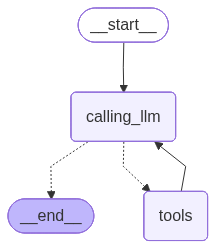

In [6]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
config = {'configurable': {"thread_id": 1}}

res = graph.invoke({"messages": "what is 49 plus 43?"}, config=config)

response = res['messages'][-1].content
print(response)

The answer to 49 plus 43 is 92.
